# 08: The two-factor Gaussian model (G2++) — decorrelation and exact simulation

## Objective

Notebook 06 fitted a **one-factor** Hull-White model. One factor means every
forward rate is driven by the same Brownian motion, so the model-implied
instantaneous correlation between any two forward rates is exactly 1 — a
documented limitation (`docs/hull-white-limitations.md`, section 2). This
notebook introduces the **two-factor Gaussian** model (Brigo & Mercurio,
*Interest Rate Models*, section 4.2), usually written **G2++**:

- state the model: a short rate that is the sum of two correlated
  mean-reverting Gaussian factors plus a deterministic shift that fits the
  initial curve exactly;
- verify the closed-form zero-coupon bond price against QuantLib's `ql.G2`
  (software verification, not model validation);
- sample the factors **exactly** (joint Gaussian transition, no
  Euler-Maruyama) and show the short-rate paths mean-revert around the
  deterministic shift;
- compute the model-implied **instantaneous correlation between two forward
  rates** and show it is strictly below 1 — the whole point of the second
  factor — in contrast to the one-factor model's forced perfect correlation;
- fit $(a, \sigma, b, \eta)$ to an illustrative caplet volatility grid (with
  $\rho$ fixed), reporting the identification diagnostics and the boundary.

As with notebooks 06 and 07, this is an educational exhibit, not a
production pricing or risk system.

## Data

**Snapshot date:** 24 July 2026. The discount curve is the USD OIS curve
bootstrapped from the snapshot's OIS swap quotes with the canonical
log-linear discount-factor bootstrap — the same curve notebook 06 uses, and
the initial term structure the G2++ shift $\phi(t)$ is constructed to match
exactly. No new market data is needed: the model fits the existing curve.

The caplet calibration target is an **illustrative** grid generated from a
reference G2++ model (deterministic, seeded), not observed caplet quotes.
Every volatility-related number below is therefore a demonstration of the
calibration workflow on a constructed target, not a market calibration.

In [1]:
from __future__ import annotations

from datetime import date

import matplotlib.pyplot as plt
import numpy as np

from yieldcurve.curves.build import usd_ois_curve
from yieldcurve.market.snapshot import Snapshot
from yieldcurve.models.g2pp import G2pp, calibrate

ASOF = date(2026, 7, 24)
SEED = 20260816
rng = np.random.default_rng(SEED)

snapshot = Snapshot(date=ASOF)
curve = usd_ois_curve(snapshot, ASOF)

# Reference parameters: two clearly separated factors, moderate correlation.
A, SIGMA, B, ETA, RHO = 0.10, 0.010, 0.25, 0.020, 0.40
model = G2pp(curve=curve, a=A, sigma=SIGMA, b=B, eta=ETA, rho=RHO)

print("=" * 70)
print("G2++: TWO-FACTOR GAUSSIAN EXAMPLE")
print("=" * 70)
print(f"Snapshot date:       {ASOF}")
print("Discount curve:      USD OIS, canonical log-linear bootstrap")
print(f"Parameters:          a={A}, sigma={SIGMA}, b={B}, eta={ETA}, rho={RHO}")
print()

G2++: TWO-FACTOR GAUSSIAN EXAMPLE
Snapshot date:       2026-07-24
Discount curve:      USD OIS, canonical log-linear bootstrap
Parameters:          a=0.1, sigma=0.01, b=0.25, eta=0.02, rho=0.4



## Theory

### The model

The short rate is the sum of two correlated mean-reverting Gaussian factors
plus a deterministic shift:

$$ r(t) = x(t) + y(t) + \phi(t), $$

$$ dx_t = -a\,x_t\,dt + \sigma\,dW_t^1, \qquad x(0) = 0, $$
$$ dy_t = -b\,y_t\,dt + \eta\,dW_t^2, \qquad y(0) = 0, $$
$$ d\langle W^1, W^2\rangle_t = \rho\,dt, \qquad a,b,\sigma,\eta>0,\;\rho\in(-1,1). $$

The shift is chosen to reproduce the initial discount curve exactly:

$$ \phi(t) = f^M(0,t) + \frac{\sigma^2}{2a^2}\left(1-e^{-at}\right)^2
   + \frac{\eta^2}{2b^2}\left(1-e^{-bt}\right)^2
   + \frac{\rho\sigma\eta}{ab}\left(1-e^{-at}\right)\left(1-e^{-bt}\right). $$

**The implementation evaluates $\phi$ only for the short-rate path and its
mean.** Bond prices need only $P^M(0,\cdot)$ and the variance below (no
derivative of the curve), and exact simulation needs only the Gaussian
transition of $(x,y)$; $\phi$ enters only as $x+y+\phi$ for the short rate
itself. This routes around $\phi$ exactly the way notebook 06's Hull-White
routes around $\theta$.

### The complete affine bond formula

The zero-coupon bond price is exponential-affine in the two state variables:

$$ P(t,T) = A(t,T)\exp\left(-B(a,t,T)\,x(t) - B(b,t,T)\,y(t)\right),
   \qquad B(z,t,T) = \frac{1-e^{-z(T-t)}}{z}, $$

$$ A(t,T) = \frac{P^M(0,T)}{P^M(0,t)}
   \exp\left\{\frac{1}{2}\left[V(t,T) - V(0,T) + V(0,t)\right]\right\}, $$

where $V(t,T)$ is the Brigo-Mercurio eq (4.12) variance of the integral of
the two factors:

$$ V(t,T) = \frac{\sigma^2}{a^2}\left[T-t + \frac{2}{a}e^{-a(T-t)}
   - \frac{1}{2a}e^{-2a(T-t)} - \frac{3}{2a}\right]
   + \frac{\eta^2}{b^2}\left[T-t + \frac{2}{b}e^{-b(T-t)}
   - \frac{1}{2b}e^{-2b(T-t)} - \frac{3}{2b}\right] $$
$$ + \frac{2\rho\sigma\eta}{ab}\left[T-t - B(a,t,T) - B(b,t,T)
   + \frac{1-e^{-(a+b)(T-t)}}{a+b}\right]. $$

The first factor of $A(t,T)$ is the market discount ratio, the second the
convexity correction from the two-factor variance. At time zero
($t=0,\ x=y=0$) the state term is 1 and $A(0,T)=P^M(0,T)$, so the model
reproduces today's curve to floating-point precision — an identity of the
construction, not a fit.

### Why two factors: decorrelation

The instantaneous forward rate is

$$ f(t,T) = -\frac{\partial}{\partial T}\ln P(t,T)
   = c(t,T) + e^{-a(T-t)}x(t) + e^{-b(T-t)}y(t), $$

affine in $(x(t),y(t))$ with *tenor-dependent* loadings
$\left(e^{-a(T-t)},\,e^{-b(T-t)}\right)$. Two forwards with different
maturities load differently on the two factors, so their instantaneous
correlation is **strictly below 1**. In the one-factor Hull-White model the
loading collapses to the single factor $e^{-a(T-t)}r(t)$, and every pair of
forwards is perfectly correlated — the limitation documented in
`docs/hull-white-limitations.md` section 2. The second factor is what lets
the curve tilt and twist instead of moving as a rigid block.

## Method

### Exact simulation

Each factor is an Ornstein-Uhlenbeck process, so the transition over a step
$[t,s]$ is Gaussian with a closed-form mean and covariance:

$$ x(s) = x(t)e^{-a(s-t)} + \sigma\sqrt{\frac{1-e^{-2a(s-t)}}{2a}}\,Z_1,
   \qquad y(s) = y(t)e^{-b(s-t)} + \eta\sqrt{\frac{1-e^{-2b(s-t)}}{2b}}\,Z_2, $$

with $\mathrm{Cov}(Z_1,Z_2)=\rho\,\frac{1-e^{-(a+b)(s-t)}}{a+b}$. The
increments are sampled **exactly** (joint Gaussian, no Euler-Maruyama
discretisation), so the only error in a path sample is Monte Carlo error.

### Forward-rate correlation

The cross-sectional correlation of $f(t,T_1)$ and $f(t,T_2)$ at a fixed
$t>0$ follows from the covariance of the loadings against the exact state
covariance of $(x(t),y(t))$:

$$ \mathrm{Corr}\left(f(t,T_1),\,f(t,T_2)\right) =
   \frac{\mathrm{Cov}\left(f(t,T_1),f(t,T_2)\right)}
        {\sqrt{\mathrm{Var}\,f(t,T_1)\cdot\mathrm{Var}\,f(t,T_2)}} < 1. $$

### Calibration

$(a,\sigma,b,\eta)$ are fitted to ATM caplet normal volatilities by least
squares; $\rho$ is a **fixed** input because caplet prices are invariant
under the factor-label swap $(a,\sigma)\leftrightarrow(b,\eta)$ and only
identify the variance structure $V(t,T)$ — not the correlation, which affects
cross-tenor dependence and is identified by swaptions/spread options (out of
scope here). The fit imposes $a\le b$ (a pure labelling convention) and
rejects boundary fits, rank-deficient/ill-conditioned Jacobians, and
start-sensitive solutions.

In [2]:
# Regression check: the affine price at time 0 reproduces the bootstrapped
# curve. Any visible error would be a bug in the shift, not a modelling gap.
tenors = np.array([0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
model_prices = np.array([model.discount_bond(0.0, t, 0.0, 0.0) for t in tenors])
curve_prices = np.array([curve.df(t) for t in tenors])
print("time-0 bond price vs input curve:")
print("  tenor(y):", [f"{t:>4}" for t in tenors])
print("  model   :", [f"{p:.8f}" for p in model_prices])
print("  curve   :", [f"{p:.8f}" for p in curve_prices])
print("  max |diff| =", f"{np.max(np.abs(model_prices - curve_prices)):.2e}")
print()

time-0 bond price vs input curve:
  tenor(y): [' 0.5', ' 1.0', ' 2.0', ' 3.0', ' 5.0', ' 7.0', '10.0']
  model   : ['0.97974626', '0.95990273', '0.91849458', '0.87975571', '0.80443788', '0.73077001', '0.62827390']
  curve   : ['0.97974626', '0.95990273', '0.91849458', '0.87975571', '0.80443788', '0.73077001', '0.62827390']
  max |diff| = 0.00e+00



## Results — a short-rate path sample and mean reversion

The short rate is $r(t)=x(t)+y(t)+\phi(t)$. Since $\mathbb{E}[x]=\mathbb{E}[y]=0$,
the model-implied mean of the short rate is exactly $\phi(t)$ — the
deterministic shift, which is the mean-reversion level the paths fluctuate
around. The paths below are sampled exactly; the solid line is $\phi(t)$.

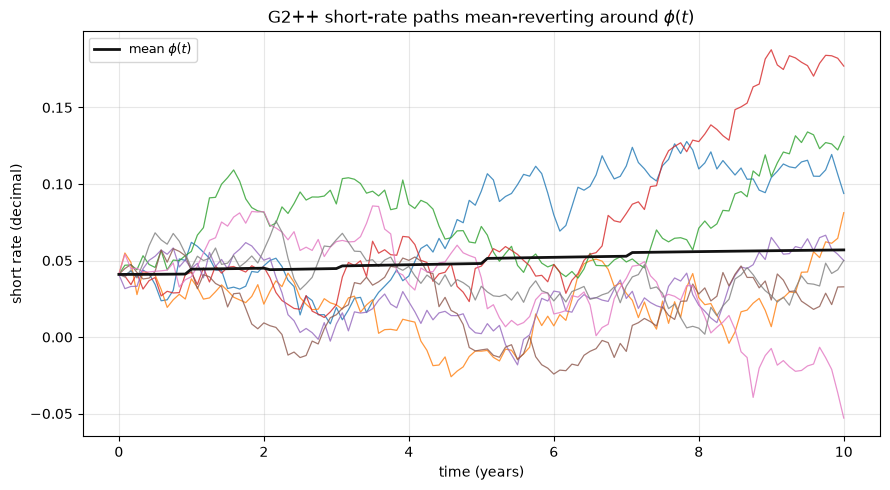

phi(0), phi(3), phi(5), phi(10): ['0.04092', '0.04475', '0.04805', '0.05693']
sample mean vs phi at t=10 (50,000 paths):
  sample mean = 0.05737,  phi(10) = 0.05693


In [3]:
horizon = 10.0
grid = np.linspace(0.0, horizon, 121)  # monthly steps
paths = model.simulate_short_rate(grid, 8, seed=SEED)
mean_paths = model.simulate_short_rate(grid, 50_000, seed=SEED + 1)
phi_path = np.array([model.phi(t) for t in grid])

fig, ax = plt.subplots(figsize=(9, 5))
for k in range(paths.shape[0]):
    ax.plot(grid, paths[k, :], lw=0.9, alpha=0.8)
ax.plot(grid, phi_path, color="#111111", lw=2.0, label=r"mean $\phi(t)$")
ax.set_xlabel("time (years)")
ax.set_ylabel("short rate (decimal)")
ax.set_title("G2++ short-rate paths mean-reverting around $\\phi(t)$")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("phi(0), phi(3), phi(5), phi(10):", [f"{model.phi(t):.5f}" for t in (0.0, 3.0, 5.0, 10.0)])
print("sample mean vs phi at t=10 (50,000 paths):")
print(f"  sample mean = {mean_paths[:, -1].mean():.5f},  phi(10) = {model.phi(10.0):.5f}")

## Results — decorrelation (the second factor's contribution)

The correlation matrix of instantaneous forward rates across tenors at a
fixed $t$ is printed and plotted. Off the diagonal it is strictly below 1 —
e.g. the 2-year and 10-year forwards are correlated at about 0.93, not 1.0.
A one-factor model would print a matrix of exactly 1s everywhere.

instantaneous forward-rate correlation at t = 1.0:
              1.0      2.0      3.0      5.0      7.0     10.0
   1.0y    1.0000   0.9990   0.9959   0.9824   0.9596   0.9133
   2.0y    0.9990   1.0000   0.9989   0.9897   0.9711   0.9304
   3.0y    0.9959   0.9989   1.0000   0.9953   0.9812   0.9465
   5.0y    0.9824   0.9897   0.9953   1.0000   0.9953   0.9733
   7.0y    0.9596   0.9711   0.9812   0.9953   1.0000   0.9910
  10.0y    0.9133   0.9304   0.9465   0.9733   0.9910   1.0000


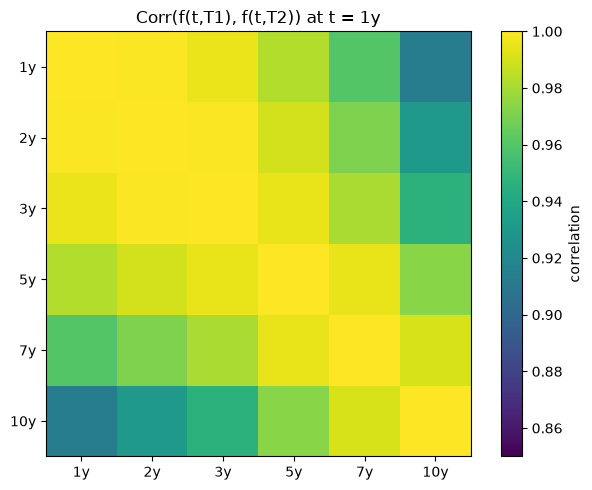

In [4]:
t_fix = 1.0
tenors_corr = np.array([1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
corr = np.array(
    [[model.forward_rate_correlation(t_fix, t1, t2) for t2 in tenors_corr] for t1 in tenors_corr]
)

print(f"instantaneous forward-rate correlation at t = {t_fix}:")
header = "        " + "".join(f"{t:>9.1f}" for t in tenors_corr)
print(header)
for t1, row in zip(tenors_corr, corr, strict=True):
    print(f"  {t1:4.1f}y " + "".join(f"{c:>9.4f}" for c in row))

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr, cmap="viridis", vmin=0.85, vmax=1.0)
ax.set_xticks(range(len(tenors_corr)), labels=[f"{t:.0f}y" for t in tenors_corr])
ax.set_yticks(range(len(tenors_corr)), labels=[f"{t:.0f}y" for t in tenors_corr])
ax.set_title(f"Corr(f(t,T1), f(t,T2)) at t = {t_fix:.0f}y")
fig.colorbar(im, ax=ax, label="correlation")
fig.tight_layout()
plt.show()

A scatter of the two forward rates makes the decorrelation visible directly:
the points form an ellipse, not a straight line. The printed correlation
matches `forward_rate_correlation` (up to Monte Carlo error from the
simulated state).

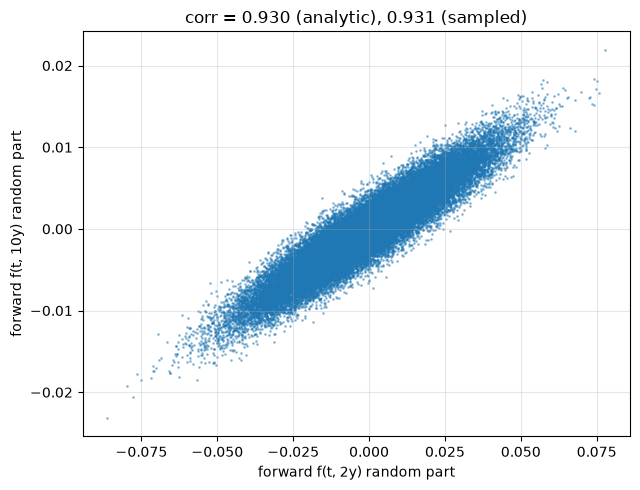

In [5]:
state = model.simulate([0.0, t_fix], 50_000, seed=SEED)[:, -1, :]
x_state, y_state = state[:, 0], state[:, 1]
T1, T2 = 2.0, 10.0
f1 = np.exp(-A * (T1 - t_fix)) * x_state + np.exp(-B * (T1 - t_fix)) * y_state
f2 = np.exp(-A * (T2 - t_fix)) * x_state + np.exp(-B * (T2 - t_fix)) * y_state
empirical = float(np.corrcoef(f1, f2)[0, 1])
analytic = model.forward_rate_correlation(t_fix, T1, T2)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(f1, f2, s=1, alpha=0.4)
ax.set_xlabel(f"forward f(t, {T1:.0f}y) random part")
ax.set_ylabel(f"forward f(t, {T2:.0f}y) random part")
ax.set_title(f"corr = {analytic:.3f} (analytic), {empirical:.3f} (sampled)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Results — calibration to an illustrative caplet grid

$(a,\sigma,b,\eta)$ are fitted (with $\rho$ fixed) to ATM caplet normal
volatilities generated from a reference model, so the recovery is exact up to
optimizer tolerance. The diagnostics — boundary flags, Jacobian rank and
condition, start sensitivity — mirror the Hull-White and SABR fits.

In [6]:
ref_a, ref_sigma, ref_b, ref_eta, ref_rho = 0.08, 0.008, 0.30, 0.020, 0.40
ref = G2pp(curve=curve, a=ref_a, sigma=ref_sigma, b=ref_b, eta=ref_eta, rho=ref_rho)


caplet_grid = [
    (0.5, 0.25),
    (0.5, 1.0),
    (1.0, 0.25),
    (1.0, 1.0),
    (2.0, 0.25),
    (2.0, 1.0),
    (3.0, 0.5),
    (5.0, 1.0),
    (7.0, 1.0),
    (10.0, 2.0),
]
quotes = []
for expiry, tenor in caplet_grid:
    forward = (curve.df(expiry) / curve.df(expiry + tenor) - 1.0) / tenor
    quotes.append((expiry, tenor, forward, ref.caplet_normal_vol(expiry, tenor, forward)))

result = calibrate(curve, quotes, rho=ref_rho)
print("caplet calibration (rho fixed at", f"{ref_rho}):")
print(f"  a     = {result.a:.4f}   (reference {ref_a})")
print(f"  sigma = {result.sigma:.4f}   (reference {ref_sigma})")
print(f"  b     = {result.b:.4f}   (reference {ref_b})")
print(f"  eta   = {result.eta:.4f}   (reference {ref_eta})")
print(f"  rmse  = {result.rmse_vol_bp:.4f} bp")
print(f"  jacobian rank = {result.jacobian_rank}, cond = {result.jacobian_condition:.2e}")
print(f"  start sensitivity = {result.start_sensitivity:.2e}")

caplet calibration (rho fixed at 0.4):
  a     = 0.0800   (reference 0.08)
  sigma = 0.0080   (reference 0.008)
  b     = 0.3000   (reference 0.3)
  eta   = 0.0200   (reference 0.02)
  rmse  = 0.0000 bp
  jacobian rank = 4, cond = 3.73e+03
  start sensitivity = 8.69e-04


## Limitations

1. **Gaussian short rate:** negative rates carry strictly positive
   probability at every horizon (the same property as Hull-White, now with
   two factors contributing). Shifted variants can enforce positivity at the
   cost of tractability.
2. **Two factors, still no smile:** a constant $(\sigma,\eta)$ produces no
   volatility smile across strikes; the caplet target here is ATM only.
3. **$\rho$ is not identified by caplets.** Caplet prices pin the variance
   $V(t,T)$ but are invariant under $(a,\sigma)\leftrightarrow(b,\eta)$ and
   carry no cross-tenor dependence, so the correlation is a fixed input, and
   the factor labels are ordered $a\le b$ by convention. A full calibration
   to swaptions (or spread options), which identify $\rho$ through
   cross-tenor decorrelation, is outside this module's scope.
4. **Illustrative target:** the caplet grid is generated from a reference
   model, not observed; the fitted parameters describe the construction, not
   a market. On real quotes the residuals would carry bid-ask and model miss.
5. **Constant parameters:** the fit is a single point in time; real surfaces
   move, and a production workflow would re-fit rolling.

## Regulatory context

The same boundary as notebooks 06 and 07 applies. This is a least-squares
fit to a constructed grid and an exact closed form, not a validated pricing
or risk model. A bank's internal model governance, independent validation
and internal-capital assessment sit under CRD Articles 74 (governance), 84
(IRRBB) and 101 (ICAAP); none of that machinery is present here. The
cross-check against QuantLib in `tests/models/test_g2pp.py` is software
verification — two implementations of the same closed form — not empirical
or regulatory model validation, and it is not a substitute for the model
validation requirements of CRR 313-314, which apply to internal models for
market-risk own funds. Under IFRS 13, an illustrative volatility is an
unobservable (Level 3) input, and no automatic fair-value classification
follows from using it; this notebook performs no entity-level fair-value
measurement.